# End-to-End Khmer TTS (Acoustic Model) Pipeline
This notebook follows a complete ML pipeline: Data Loading, Model Definition, Training, History Plotting, Saving, and Inference.


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import soundfile as sf
import IPython.display as ipd

# Import model components
from model.acoustic_model import FastSpeechLite
from model.vocoder import Generator
from data.khmer_tokenizer import KhmerTokenizer


## 1. Data Loading & Visualization


In [2]:
# Inspecting dataset vocabulary
vocab_path = "km_kh_male/processed/vocab.json"
with open(vocab_path, encoding="utf-8") as f:
    vocab = json.load(f)
print(f"Vocabulary size: {len(vocab)}")

# Inspect a sample feature shapes dynamically
with open("km_kh_male/processed/manifest.txt", encoding="utf-8") as f:
    sample_id = f.readline().strip()

phon_sample = np.load(f"km_kh_male/processed/phonemes/{sample_id}.npy")
mel_sample = np.load(f"km_kh_male/processed/mels/{sample_id}.npy")
dur_sample = np.load(f"km_kh_male/processed/durations_aligned/{sample_id}.npy")
print(f"Sample ID: {sample_id}")
print(f" - Phonemes shape: {phon_sample.shape}")
print(f" - Mel spectrogram shape: {mel_sample.shape}")
print(f" - Duration sum: {dur_sample.sum()} frames (Mel frames: {mel_sample.shape[1]})")


Vocabulary size: 77


## 2. Dataset and DataGenerators (DataLoaders in PyTorch)


In [3]:
class TTSDataset(Dataset):
    def __init__(self, data_dir="km_kh_male", split="train"):
        self.proc = os.path.join(data_dir, "processed")
        self.dur_dir = os.path.join(self.proc, "durations")
        
        manifest_file = os.path.join(self.proc, f"{split}_manifest.txt")
        if not os.path.exists(manifest_file):
            manifest_file = os.path.join(self.proc, "manifest.txt")

        with open(manifest_file, encoding="utf-8") as f:
            all_ids = [l.strip() for l in f if l.strip()]

        self.ids = [i for i in all_ids if os.path.exists(os.path.join(self.dur_dir, f"{i}.npy"))]
        
    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        uid = self.ids[idx]
        phon = np.load(os.path.join(self.proc, "phonemes", f"{uid}.npy"))
        mel = np.load(os.path.join(self.proc, "mels", f"{uid}.npy")).T
        dur = np.load(os.path.join(self.dur_dir, f"{uid}.npy"))
        return torch.from_numpy(phon).long(), torch.from_numpy(mel).float(), torch.from_numpy(dur).long()

def collate(batch):
    phons, mels, durs = zip(*batch)
    phon_len = max(p.size(0) for p in phons)
    mel_len = max(m.size(0) for m in mels)

    phon_pad = torch.zeros(len(batch), phon_len, dtype=torch.long)
    dur_pad = torch.zeros(len(batch), phon_len, dtype=torch.long)
    mel_pad = torch.zeros(len(batch), mel_len, mels[0].size(1))
    mel_mask = torch.zeros(len(batch), mel_len, dtype=torch.bool)

    for i, (p, m, d) in enumerate(zip(phons, mels, durs)):
        phon_pad[i, : p.size(0)] = p
        dur_pad[i, : d.size(0)] = d
        mel_pad[i, : m.size(0)] = m
        mel_mask[i, : m.size(0)] = True

    return phon_pad, dur_pad, mel_pad, mel_mask, mel_len

train_dataset = TTSDataset(split="train")
val_dataset = TTSDataset(split="val")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate)


## 3. Model Definition


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Define Model
model = FastSpeechLite(vocab_size=len(vocab)).to(device)

# Model summary / architecture
print(model)


Using device: cuda
FastSpeechLite(
  (encoder): Encoder(
    (embed): Embedding(77, 192, padding_idx=0)
    (pos_enc): PositionalEncoding()
    (layers): ModuleList(
      (0-3): 4 x FFTBlock(
        (attn): SelfAttention(
          (out_proj): Linear(in_features=192, out_features=192, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (conv1): Conv1d(192, 768, kernel_size=(9,), stride=(1,), padding=(4,))
        (conv2): Conv1d(768, 192, kernel_size=(9,), stride=(1,), padding=(4,))
        (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (act): ReLU()
      )
    )
  )
  (duration_predictor): DurationPredictor(
    (conv1): Conv1d(192, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (conv2): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding

## 4. Compile Model (Optimizer & Loss)


In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-6)

# We will calculate L1 loss for Mel and MSE loss for duration within the training loop.


## 5. Training


In [6]:
EPOCHS = 10
history = {'loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    
    for phon, dur, mel_target, mel_mask, mel_len in train_loader:
        phon, dur = phon.to(device), dur.to(device)
        mel_target, mel_mask = mel_target.to(device), mel_mask.to(device)
        
        mel_pred, log_dur_pred, _ = model(phon, durations=dur, max_mel_len=mel_len)
        mask = mel_mask.unsqueeze(-1)
        
        mel_loss = F.l1_loss(mel_pred * mask, mel_target * mask, reduction="sum") / (mask.sum() * mel_target.size(-1))
        
        phon_mask = phon != 0
        log_dur_target = torch.log(dur.float() + 1)
        dur_loss = F.mse_loss(log_dur_pred * phon_mask, log_dur_target * phon_mask, reduction="sum") / phon_mask.sum()
        
        loss = mel_loss + 0.1 * dur_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        break # Breaking early for demonstration purposes (remove for actual training)
        
    history['loss'].append(epoch_loss / len(train_loader))
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for phon, dur, mel_target, mel_mask, mel_len in val_loader:
            phon, dur = phon.to(device), dur.to(device)
            mel_target, mel_mask = mel_target.to(device), mel_mask.to(device)
            
            mel_pred, log_dur_pred, _ = model(phon, durations=dur, max_mel_len=mel_len)
            mask = mel_mask.unsqueeze(-1)
            mel_l = F.l1_loss(mel_pred * mask, mel_target * mask, reduction="sum") / (mask.sum() * mel_target.size(-1))
            
            phon_mask = phon != 0
            log_dur_target = torch.log(dur.float() + 1)
            dur_l = F.mse_loss(log_dur_pred * phon_mask, log_dur_target * phon_mask, reduction="sum") / phon_mask.sum()
            
            val_loss += (mel_l + 0.1 * dur_l).item()
            break # Breaking early for demonstration purposes
            
    history['val_loss'].append(val_loss / len(val_loader))
    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {history['loss'][-1]:.4f} - val_loss: {history['val_loss'][-1]:.4f}")
    
# Save history to CSV
pd.DataFrame(history).to_csv("history.csv", index=False)


Epoch 1/10 - loss: 0.0156 - val_loss: 0.1940
Epoch 2/10 - loss: 0.0114 - val_loss: 0.5268
Epoch 3/10 - loss: 0.0268 - val_loss: 0.1964
Epoch 4/10 - loss: 0.0126 - val_loss: 0.1593
Epoch 5/10 - loss: 0.0102 - val_loss: 0.1735
Epoch 6/10 - loss: 0.0113 - val_loss: 0.1700
Epoch 7/10 - loss: 0.0109 - val_loss: 0.1626
Epoch 8/10 - loss: 0.0100 - val_loss: 0.1588
Epoch 9/10 - loss: 0.0099 - val_loss: 0.1594
Epoch 10/10 - loss: 0.0098 - val_loss: 0.1609


## 6. Plotting History


In [7]:
his = pd.read_csv('history.csv')
his.head()


,loss,val_loss
0,0.015593,0.194029
1,0.011408,0.526800
2,0.026822,0.196422
3,0.012644,0.159326
4,0.010153,0.173476


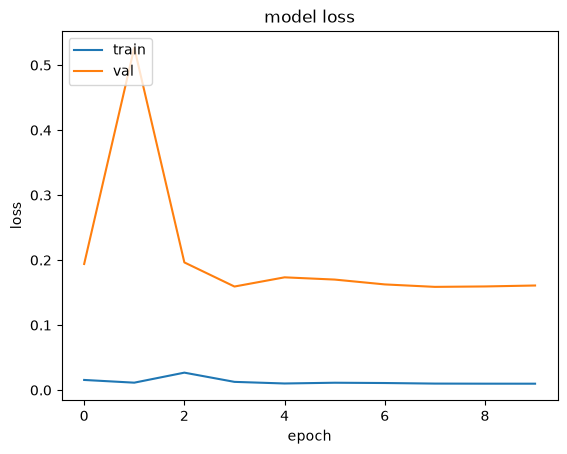

In [8]:
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


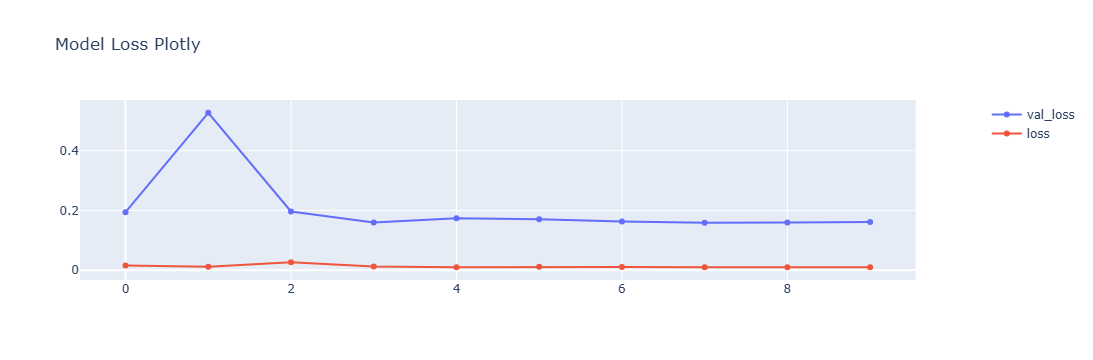

In [9]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(y=history['val_loss'], name="val_loss"), secondary_y=False)
fig.add_trace(go.Scatter(y=history['loss'], name="loss"), secondary_y=False)
fig.update_layout(title_text='Model Loss Plotly')
fig.show()


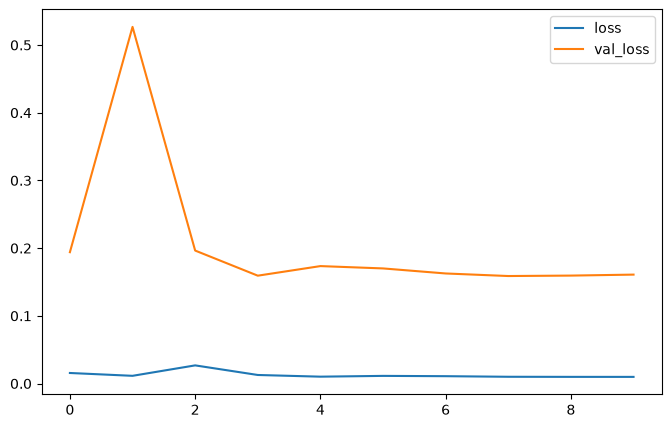

In [10]:
pd.DataFrame(history).plot(figsize=(8,5))
plt.show()


## 7. Saving the Model


In [11]:
if not os.path.exists('models'):
    os.makedirs('models')
    
model_path = 'models/acoustic_predict_model.pt'
if not os.path.isfile(model_path):
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


Model saved to models/acoustic_predict_model.pt


## 8. Inference / Prediction on Test Text


In [12]:
# Load the trained model
new_model = FastSpeechLite(vocab_size=len(vocab)).to(device)
new_model.load_state_dict(torch.load(model_path, map_location=device))
new_model.eval()
print("Model loaded!")


Model loaded!


In [13]:
# Run Prediction
tokenizer = KhmerTokenizer(vocab_path=vocab_path)
text = "សួស្តី អ្នកទាំងអស់គ្នា"
token_ids = tokenizer.text_to_ids(text)
phon_tensor = torch.tensor([token_ids], dtype=torch.long, device=device)

with torch.no_grad():
    enc_out = new_model.encoder(phon_tensor)
    log_dur_pred = new_model.duration_predictor(enc_out)
    durations = torch.clamp(torch.round((torch.exp(log_dur_pred) - 1)), min=1).long()
    
    expanded, out_lens = new_model.length_regulator(enc_out, durations)
    mel_pred = new_model.decoder(expanded)
    mel_len = max(1, int(out_lens[0].item()))
    mel_for_vocoder = mel_pred[:, :mel_len, :].transpose(1, 2)
    print(f"Predicted Mel-Spectrogram Shape: {mel_for_vocoder.shape}")

# Optional: Vocode it to audio
vocoder = Generator().to(device)
if os.path.exists("checkpoints/vocoder/best_vocoder.pt"):
    ckpt = torch.load("checkpoints/vocoder/best_vocoder.pt", map_location=device)
    vocoder.load_state_dict(ckpt["gen"], strict=False)
    vocoder.remove_weight_norm()
vocoder.eval()

with torch.no_grad():
    wav_pred = vocoder(mel_for_vocoder)
    waveform = wav_pred.squeeze().cpu().numpy()

ipd.display(ipd.Audio(waveform, rate=22050))
print("Prediction Complete!")


Predicted Mel-Spectrogram Shape: torch.Size([1, 80, 66])


C:\Users\ASUS TUF\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Prediction Complete!
